In [1]:
import sys
sys.path.insert(0, '../src')
from config import FEATURE_COLS

print(f"Total features: {len(FEATURE_COLS)}")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2}. {f}")

Total features: 19
   1. url_length
   2. num_dots
   3. num_hyphens
   4. num_underscores
   5. num_slashes
   6. num_at
   7. num_question
   8. num_equals
   9. num_percent
  10. num_digits_in_domain
  11. num_digits_in_path
  12. last_path_segment_is_integer
  13. has_ip
  14. has_https
  15. num_subdomains
  16. hostname_length
  17. path_length
  18. double_slash
  19. num_suspicious_words


In [2]:
import sys
sys.path.insert(0, '../src')
from features.unified_extractor import extract_all

test_urls = [
    ('http://192.168.0.45/secure-login',          'Phishing — IP-based'),
    ('http://bankofegypt-login.evil.com/confirm',  'Phishing — Brand impersonation'),
    ('https://www.google.com',                     'Legitimate'),
]

for url, label in test_urls:
    f = extract_all(url)
    print(f"\n[{label}]")
    print(f"  URL                  : {url}")
    print(f"  has_ip               : {f['has_ip']}")
    print(f"  has_https            : {f['has_https']}")
    print(f"  num_suspicious_words : {f['num_suspicious_words']}")
    print(f"  num_subdomains       : {f['num_subdomains']}")
    print(f"  url_length           : {f['url_length']}")


[Phishing — IP-based]
  URL                  : http://192.168.0.45/secure-login
  has_ip               : 1
  has_https            : 0
  num_suspicious_words : 2
  num_subdomains       : 2
  url_length           : 32

[Phishing — Brand impersonation]
  URL                  : http://bankofegypt-login.evil.com/confirm
  has_ip               : 0
  has_https            : 0
  num_suspicious_words : 1
  num_subdomains       : 1
  url_length           : 41

[Legitimate]
  URL                  : https://www.google.com
  has_ip               : 0
  has_https            : 1
  num_suspicious_words : 0
  num_subdomains       : 1
  url_length           : 22


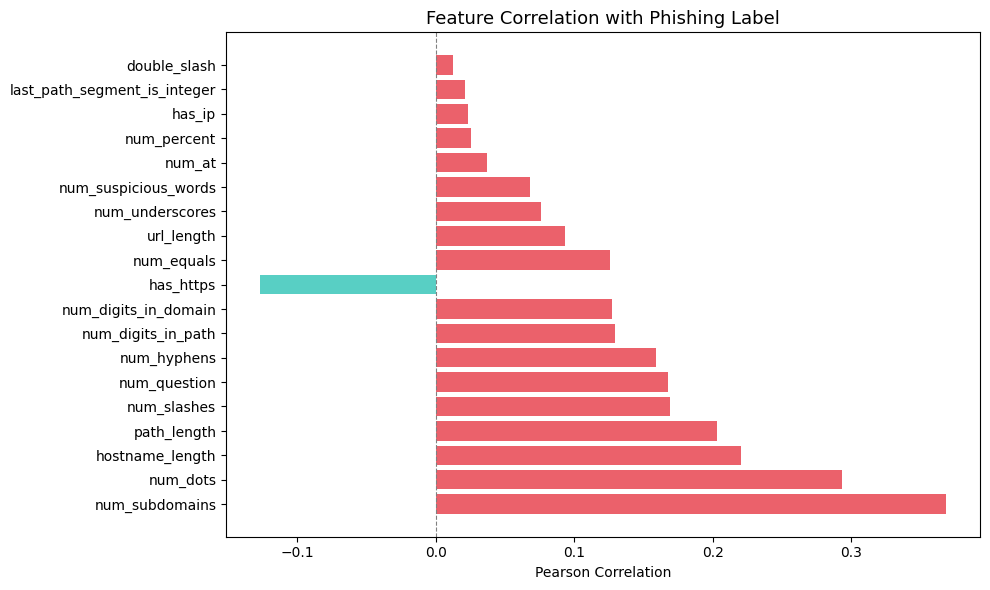

Top positive correlators (→ phishing):
num_subdomains     0.368248
num_dots           0.293024
hostname_length    0.220670
path_length        0.203345
num_slashes        0.169061


In [3]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
from config import FEATURE_COLS

df = pd.read_csv('../data/processed/phishtrace_features.csv')
corr = df[FEATURE_COLS + ['label']].corr()['label'].drop('label').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#e63946' if v > 0 else '#2ec4b6' for v in corr.values]
plt.barh(corr.index, corr.values, color=colors, alpha=0.8)
plt.title('Feature Correlation with Phishing Label', fontsize=13)
plt.xlabel('Pearson Correlation')
plt.axvline(0, color='gray', lw=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('../reports/figures/feature_correlation.png', dpi=120)
plt.show()
print("Top positive correlators (→ phishing):")
print(corr[corr > 0].head(5).to_string())